# Multi-dataset immune integration: RNA Data Loading

Load 7 multiome datasets (RNA only), harmonize annotations and metadata, compute QC metrics, and save combined h5ad.
**No cell or gene filtering** — filtering is done in the training notebook after inspecting both RNA and ATAC QC metrics.

**Datasets:**
1. Bone marrow (NeurIPS 2021) — 13 batches, ~69k cells
2. TEA-seq PBMC (GSE158013) — 7 samples, ~52k cells
3. NEAT-seq CD4 T (GSE178707) — 2 lanes, ~8.5k cells
4. Crohn's PBMC (GSE244831) — 13 samples, ~76k cells
5. COVID infant PBMC (GSE239799) — 43 samples, no annotations
6. Lung/Spleen immune (GSE319044) — 16 samples, ~54k cells
7. Infant/Adult Spleen (GSE311423) — 5 samples, no annotations

**Outputs:**
- `results/immune_integration/adata_rna.h5ad` — all cells, with RNA QC metrics
- `results/immune_integration/obs_metadata.csv` — full obs table
- `results/immune_integration/path_sample_df.csv` — fragment paths for SnapATAC2 jobs

See `PLAN.md` for full details.

In [1]:
import gc
import os
import sys

import anndata
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib import rcParams

# Add notebook directory to path for data_loading_utils
sys.path.insert(0, os.path.join(os.getcwd(), "docs", "notebooks", "immune_integration"))

from data_loading_utils import (
    load_bone_marrow,
    load_covid_pbmc_gse239799,
    load_crohns_pbmc_gse244831,
    load_infant_adult_spleen_gse311423,
    load_lung_spleen_gse319044,
    load_neat_seq_cd4t,
    load_tea_seq_pbmc,
)

rcParams["pdf.fonttype"] = 42

In [2]:
results_folder = "/nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/results/immune_integration/"
data_folder_global = "/nfs/team283/vk7/sanger_projects/large_data/"

In [3]:
os.makedirs(results_folder, exist_ok=True)

## 1. Load all datasets (RNA)

In [4]:
adata_bm = load_bone_marrow(data_folder=f"{data_folder_global}bone_marrow/")

Found /nfs/team283/vk7/sanger_projects/large_data/bone_marrow/bmmc_multiome_multivi_neurips21_curated.h5ad
Found /nfs/team283/vk7/sanger_projects/large_data/bone_marrow/s1d1/atac_fragments.tsv.gz
Found /nfs/team283/vk7/sanger_projects/large_data/bone_marrow/s1d1/atac_fragments.tsv.gz.tbi
Found /nfs/team283/vk7/sanger_projects/large_data/bone_marrow/s1d2/atac_fragments.tsv.gz
Found /nfs/team283/vk7/sanger_projects/large_data/bone_marrow/s1d2/atac_fragments.tsv.gz.tbi
Found /nfs/team283/vk7/sanger_projects/large_data/bone_marrow/s1d3/atac_fragments.tsv.gz
Found /nfs/team283/vk7/sanger_projects/large_data/bone_marrow/s1d3/atac_fragments.tsv.gz.tbi
Found /nfs/team283/vk7/sanger_projects/large_data/bone_marrow/s2d1/atac_fragments.tsv.gz
Found /nfs/team283/vk7/sanger_projects/large_data/bone_marrow/s2d1/atac_fragments.tsv.gz.tbi
Found /nfs/team283/vk7/sanger_projects/large_data/bone_marrow/s2d4/atac_fragments.tsv.gz
Found /nfs/team283/vk7/sanger_projects/large_data/bone_marrow/s2d4/atac_frag

/nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/docs/notebooks/immune_integration/data_loading_utils.py:227: UserWarning: Hierarchy entries not referenced by any harmonization mapping: ['CD4+ T', 'CD8+ T']. These may be kept for future datasets.
  return _get_validated_data()[0]
/nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/docs/notebooks/immune_integration/data_loading_utils.py:227: UserWarning: Cross-level name overlap (structural collapses, not necessarily errors):
  - level_3 values also in level_1: ['HSCs']
  - level_3 values also in level_2: ['HSCs', 'Myeloid lineage']
  - level_2 values also in level_1: ['Erythroid lineage', 'HSCs', 'Lymph prog', 'MK/E prog', 'NK-cell lineage', 'Platelet']
  return _get_validated_data()[0]


Bone marrow dataset: 69247 cells x 25629 genes
  Batches:  13 (['s1d1', 's1d2', 's1d3', 's2d1', 's2d4']...)
  Sites:    4
  Donors:   10
  Cell types (harmonized): 22


In [5]:
adata_tea = load_tea_seq_pbmc(data_folder=f"{data_folder_global}tea_seq_pbmc/")

/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


...

/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/docs/notebooks/immune_integration/data_loading_utils.py:786: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['CD4 TCM' 'CD4 TCM' 'CD14 Mono' ... 'CD4 TCM' nan 'CD4 Naive']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  annotations.loc[well_mask] = raw_bcs.map(well_annot).values


TEA-seq: annotated 26165/59151 cells from Figure4 CSV


TEA-seq UUID barcode mapping: 51692 entries
  UUID mapped: 52774/59151


In [6]:
adata_neat = load_neat_seq_cd4t(data_folder=f"{data_folder_global}neat_seq_pbmc/")

In [7]:
adata_crohns = load_crohns_pbmc_gse244831(data_folder=f"{data_folder_global}multiome_pbmc/GSE244831/")

  Loading Sample_0...


  Loading Sample_1...


  Loading Sample_2...


  Loading Pool_2...


  Loading Pool_3...


...

  Loading Pool_10...


  Loading Pool_11...


  Concatenated: 106296 cells x 36601 genes


  Annotations matched: 76453/106296 cells


Crohn's PBMC dataset: 106296 cells x 36601 genes
  Batches:  13 (['Sample_0', 'Sample_1', 'Sample_2', 'Pool_2', 'Pool_3']...)
  Sites:    1
  Donors:   41
  Conditions: ['healthy', 'unknown', 'crohns', 'possible_ibd']
  Cell types (harmonized): 17


In [8]:
adata_covid = load_covid_pbmc_gse239799(data_folder=f"{data_folder_global}multiome_pbmc/GSE239799/")

COVID PBMC GSE239799 dataset: 360624 cells x 36601 genes
  Samples: 43
  Donors:  25


In [9]:
adata_lung_spleen = load_lung_spleen_gse319044(data_folder=f"{data_folder_global}multiome_spleen_lung/GSE319044/")

  Loaded lung_COB-11: 5646 cells x 36601 genes


  Loaded lung_COB-5: 20000 cells x 36601 genes


  Loaded lung_COB-6: 10999 cells x 36601 genes


  Loaded lung_SMO-05: 3001 cells x 36601 genes


  Loaded lung_SMO-07: 10055 cells x 36601 genes


...

  Loaded spleen_SMO-1: 8398 cells x 36601 genes


Concatenated: 132241 cells x 36601 genes


Annotation match: 41909 / 132241 cells (31.7%)


/nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/docs/notebooks/immune_integration/data_loading_utils.py:1171: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['CD4_T' 'Memory_B' 'Naive_B' ... 'Memory_B' 'Naive_B' 'Memory_B']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  adata.obs.loc[common_cells, "original_annotation"] = ann_matched["CellType"].values
/nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/docs/notebooks/immune_integration/data_loading_utils.py:1174: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['level_1:CD4+ T-cell lineage' 'Memory B' 'Naive B' ... 'Memory B'
 'Naive B' 'Memory B']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  adata.obs.loc[common_cells, "harmonized_annotation"] = (


Lung/spleen GSE319044 dataset: 132241 cells x 36601 genes
  Batches:  16 (['lung_COB-11', 'lung_COB-5', 'lung_COB-6', 'lung_SMO-05', 'lung_SMO-07']...)
  Sites:    1
  Donors:   16
  Tissues:  {'lung': 82088, 'spleen': 50153}
  Cell types (harmonized): 5
  Annotated cells: 41909 / 132241


In [10]:
adata_spleen311 = load_infant_adult_spleen_gse311423(data_folder=f"{data_folder_global}multiome_spleen_lung/GSE311423/")

/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


...

/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Infant/adult spleen (GSE311423): 40726 cells x 36601 genes
  Batches:    5 (['LI004', 'LI018', 'HDL163', 'PDC142', 'PDC149'])
  Donors:     5 (['infant_1', 'infant_2', 'infant_3', 'adult_1', 'adult_2'])
  Age groups: ['infant', 'adult']


### Per-dataset summary

In [11]:
datasets = {
    "bone_marrow": adata_bm,
    "pbmc_tea_seq": adata_tea,
    "neat_seq_cd4t": adata_neat,
    "crohns_pbmc": adata_crohns,
    "covid_pbmc": adata_covid,
    "lung_spleen_gse319044": adata_lung_spleen,
    "infant_adult_spleen": adata_spleen311,
}

summary_rows = []
for name, ad in datasets.items():
    n_annot = ad.obs["harmonized_annotation"].notna().sum()
    summary_rows.append(
        {
            "dataset": name,
            "n_cells": ad.n_obs,
            "n_genes": ad.n_vars,
            "n_batches": ad.obs["batch"].nunique(),
            "n_donors": ad.obs["donor"].nunique(),
            "n_annotated": n_annot,
            "pct_annotated": f"{100 * n_annot / ad.n_obs:.1f}%",
        }
    )
summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,dataset,n_cells,n_genes,n_batches,n_donors,n_annotated,pct_annotated
0,bone_marrow,69247,25629,13,10,69247,100.0%
1,pbmc_tea_seq,59151,36601,7,1,26165,44.2%
2,neat_seq_cd4t,8457,36717,2,1,8457,100.0%
3,crohns_pbmc,106296,36601,13,41,69156,65.1%
4,covid_pbmc,360624,36601,43,25,0,0.0%
5,lung_spleen_gse319044,132241,36601,16,16,20310,15.4%
6,infant_adult_spleen,40726,36601,5,5,0,0.0%


## 2. Combine RNA

In [12]:
# Gene intersection across all datasets (ENSEMBL IDs)
gene_sets = [set(ad.var_names) for ad in datasets.values()]
common_genes = gene_sets[0]
for gs in gene_sets[1:]:
    common_genes = common_genes.intersection(gs)
common_genes = sorted(common_genes)
print(f"Common genes across all datasets: {len(common_genes)}")

# Save SYMBOL mapping before concat (take from first dataset)
first_ad = list(datasets.values())[0]
symbol_map = first_ad[:, common_genes].var["SYMBOL"].copy()

# Subset each dataset to common genes
adatas_subset = [ad[:, common_genes].copy() for ad in datasets.values()]

# Free individual datasets
del adata_bm, adata_tea, adata_neat, adata_crohns, adata_covid, adata_lung_spleen, adata_spleen311
del datasets
gc.collect()

Common genes across all datasets: 25629


1359

In [13]:
# Concatenate (keep source dtypes — uint16 cast only before saving)
adata = anndata.concat(adatas_subset, join="inner")

# Verify obs_names are unique (guaranteed by {batch}-{barcode} format)
assert adata.obs_names.is_unique, f"Duplicate obs_names: {adata.obs_names[adata.obs_names.duplicated()][:5].tolist()}"

# Restore SYMBOL column (lost during concat)
adata.var["SYMBOL"] = symbol_map.loc[adata.var_names].values
del symbol_map

print(f"Combined: {adata.n_obs} cells x {adata.n_vars} genes")
print(f"X dtype: {adata.X.dtype}")
print(f"Datasets: {adata.obs['dataset'].value_counts().to_dict()}")

del adatas_subset
gc.collect()

Combined: 776742 cells x 25629 genes
X dtype: float64
Datasets: {'covid_pbmc': 360624, 'lung_spleen_gse319044': 132241, 'crohns_pbmc': 106296, 'bone_marrow': 69247, 'pbmc_tea_seq': 59151, 'infant_adult_spleen': 40726, 'neat_seq_cd4t': 8457}


0

## 3. QC — RNA metrics

In [14]:
# Identify mitochondrial genes
adata.var["mt"] = adata.var["SYMBOL"].str.startswith("MT-") | adata.var["SYMBOL"].str.startswith("mt-")
print(f"MT genes: {adata.var['mt'].sum()}")

# Compute QC metrics
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, layer="counts")
adata.obs.rename(
    columns={
        "n_genes_by_counts": "n_genes",
        "pct_counts_mt": "mt_frac",
    },
    inplace=True,
)
# total_counts already correct from sc.pp.calculate_qc_metrics
# mt_frac is percentage, convert to fraction
adata.obs["mt_frac"] = adata.obs["mt_frac"] / 100.0

MT genes: 13


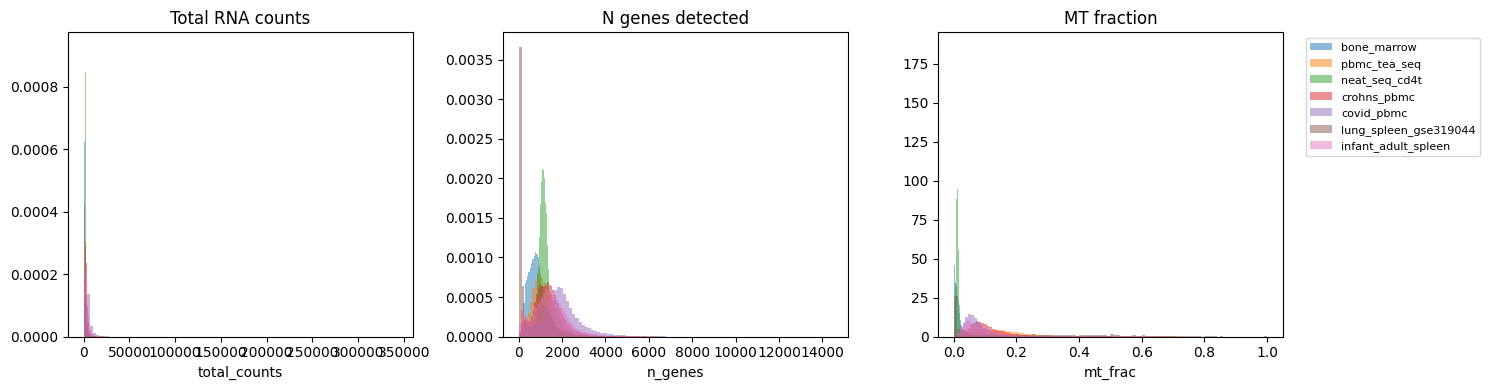

In [15]:
# QC distributions per dataset
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for metric, ax, title in zip(
    ["total_counts", "n_genes", "mt_frac"],
    axes,
    ["Total RNA counts", "N genes detected", "MT fraction"],
    strict=True,
):
    for ds in adata.obs["dataset"].unique():
        vals = adata.obs.loc[adata.obs["dataset"] == ds, metric]
        ax.hist(vals, bins=100, alpha=0.5, label=ds, density=True)
    ax.set_title(title)
    ax.set_xlabel(metric)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [16]:
# QC summary per dataset (same thresholds as NB5 training)
print("=== QC summary (NB5 thresholds) ===\n")
print(
    f"{'Dataset':<30} {'n_cells':>8} {'med_counts':>11} {'med_genes':>10} {'med_mt':>8} "
    f"{'pass_counts':>12} {'pass_genes':>11} {'pass_mt':>9}"
)
print("-" * 110)

for ds in sorted(adata.obs["dataset"].unique()):
    obs_ds = adata.obs[adata.obs["dataset"] == ds]
    n = len(obs_ds)
    med_counts = obs_ds["total_counts"].median()
    med_genes = obs_ds["n_genes"].median()
    med_mt = obs_ds["mt_frac"].median()
    pass_counts = ((obs_ds["total_counts"] > 1500) & (obs_ds["total_counts"] < 80000)).sum()
    pass_genes = ((obs_ds["n_genes"] > 800) & (obs_ds["n_genes"] < 10000)).sum()
    pass_mt = (obs_ds["mt_frac"] < 0.20).sum()
    print(
        f"{ds:<30} {n:>8,} {med_counts:>11,.0f} {med_genes:>10,.0f} {med_mt:>8.4f} "
        f"{pass_counts:>8,} ({100 * pass_counts / n:4.1f}%) {pass_genes:>7,} ({100 * pass_genes / n:4.1f}%) "
        f"{pass_mt:>5,} ({100 * pass_mt / n:4.1f}%)"
    )

# Overall
print("-" * 110)
n = adata.n_obs
med_counts = adata.obs["total_counts"].median()
med_genes = adata.obs["n_genes"].median()
med_mt = adata.obs["mt_frac"].median()
mask_all = (
    (adata.obs["n_genes"] > 800)
    & (adata.obs["total_counts"] > 1500)
    & (adata.obs["total_counts"] < 80000)
    & (adata.obs["n_genes"] < 10000)
    & (adata.obs["mt_frac"] < 0.20)
)
n_pass = mask_all.sum()
print(
    f"{'TOTAL':<30} {n:>8,} {med_counts:>11,.0f} {med_genes:>10,.0f} {med_mt:>8.4f} "
    f"               {n_pass:>8,} / {n:,} pass RNA QC ({100 * n_pass / n:.1f}%)"
)

=== QC summary (NB5 thresholds) ===

Dataset                         n_cells  med_counts  med_genes   med_mt  pass_counts  pass_genes   pass_mt
--------------------------------------------------------------------------------------------------------------
bone_marrow                      69,247       1,152        810   0.0056   22,046 (31.8%)  35,336 (51.0%) 69,247 (100.0%)


covid_pbmc                      360,624       4,112      1,915   0.0636  318,106 (88.2%) 325,952 (90.4%) 353,190 (97.9%)
crohns_pbmc                     106,296       2,379      1,322   0.0974   80,738 (76.0%)  87,790 (82.6%) 96,478 (90.8%)
infant_adult_spleen              40,726       2,799      1,405   0.0738   31,419 (77.1%)  32,855 (80.7%) 37,035 (90.9%)
lung_spleen_gse319044           132,241         241        155   0.1111   42,443 (32.1%)  46,478 (35.1%) 76,842 (58.1%)


neat_seq_cd4t                     8,457       1,998      1,143   0.0110    7,420 (87.7%)   8,232 (97.3%) 8,457 (100.0%)
pbmc_tea_seq                     59,151       2,026      1,095   0.1375   40,742 (68.9%)  43,173 (73.0%) 42,847 (72.4%)
--------------------------------------------------------------------------------------------------------------
TOTAL                           776,742       2,700      1,425   0.0674                 528,392 / 776,742 pass RNA QC (68.0%)


## 4. Save RNA + generate fragment path CSV

Save unfiltered RNA with QC metrics. Also generate `path_sample_df.csv` for SnapATAC2 job submission.
Scrublet doublet detection is done in a separate notebook (`bm_pbmc_scrublet.ipynb`).

In [17]:
# Drop failed libraries: batches where <10% cells have >1500 total counts
min_counts_lib = 1500
min_pct_above_lib = 0.10

failed_batches = []
for batch in adata.obs["batch"].unique():
    pct_above = (adata.obs.loc[adata.obs["batch"] == batch, "total_counts"] > min_counts_lib).mean()
    if pct_above < min_pct_above_lib:
        failed_batches.append(batch)

if failed_batches:
    n_before = adata.n_obs
    print(
        f"Dropping {len(failed_batches)} failed libraries (<{min_pct_above_lib:.0%} cells above {min_counts_lib} counts):"
    )
    for b in failed_batches:
        n_b = (adata.obs["batch"] == b).sum()
        ds = adata.obs.loc[adata.obs["batch"] == b, "dataset"].iloc[0]
        print(f"  {b} ({ds}): {n_b:,} cells")
    adata = adata[~adata.obs["batch"].isin(failed_batches)].copy()
    print(f"\n{n_before:,} -> {adata.n_obs:,} cells ({n_before - adata.n_obs:,} removed)")
else:
    print("All batches pass library quality check")

Dropping 7 failed libraries (<10% cells above 1500 counts):
  lung_COB-11 (lung_spleen_gse319044): 5,646 cells
  lung_COB-5 (lung_spleen_gse319044): 20,000 cells
  lung_COB-6 (lung_spleen_gse319044): 10,999 cells


  spleen_COB-10 (lung_spleen_gse319044): 4,567 cells
  spleen_COB-7 (lung_spleen_gse319044): 12,194 cells
  spleen_COB-8 (lung_spleen_gse319044): 7,857 cells
  spleen_COB-9 (lung_spleen_gse319044): 9,157 cells



776,742 -> 706,322 cells (70,420 removed)


In [18]:
# Convert to uint16 before saving (QC metrics already computed on uint32)
adata.X = adata.X.tocsr().astype(np.uint16)
adata.layers["counts"] = adata.X.copy()
print(f"X dtype for saving: {adata.X.dtype}")

# Save RNA (unfiltered — all cells with RNA QC metrics)
rna_path = os.path.join(results_folder, "adata_rna.h5ad")
adata.write_h5ad(rna_path)
print(f"Saved RNA: {rna_path}")
print(f"  Shape: {adata.shape}")
print(f"  obs columns: {list(adata.obs.columns)}")

# Save obs as CSV for inspection
obs_path = os.path.join(results_folder, "obs_metadata.csv")
adata.obs.to_csv(obs_path)
print(f"Saved obs metadata: {obs_path}")

# RNA summary
print("\nDatasets:")
for ds in sorted(adata.obs["dataset"].unique()):
    n = (adata.obs["dataset"] == ds).sum()
    n_annot = adata.obs.loc[adata.obs["dataset"] == ds, "harmonized_annotation"].notna().sum()
    print(f"  {ds}: {n} cells ({n_annot} annotated)")
print(f"\nTotal batches: {adata.obs['batch'].nunique()}")
print(f"Total donors: {adata.obs['donor'].nunique()}")
print(f"Total cell types (harmonized): {adata.obs['harmonized_annotation'].dropna().nunique()}")

X dtype for saving: uint16


Saved RNA: /nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/results/immune_integration/adata_rna.h5ad
  Shape: (706322, 25629)
  obs columns: ['batch', 'site', 'donor', 'dataset', 'tissue', 'condition', 'age_group', 'sex', 'original_annotation', 'harmonized_annotation', 'level_1', 'level_2', 'level_3', 'level_4', 'fragment_file_path', 'n_genes', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'mt_frac']


Saved obs metadata: /nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/results/immune_integration/obs_metadata.csv

Datasets:
  bone_marrow: 69247 cells (69247 annotated)
  covid_pbmc: 360624 cells (0 annotated)
  crohns_pbmc: 106296 cells (69156 annotated)
  infant_adult_spleen: 40726 cells (0 annotated)
  lung_spleen_gse319044: 61821 cells (20310 annotated)
  neat_seq_cd4t: 8457 cells (8457 annotated)
  pbmc_tea_seq: 59151 cells (26165 annotated)

Total batches: 92
Total donors: 92
Total cell types (harmonized): 49


In [19]:
# Generate path_sample_df.csv for SnapATAC2 job submission
# Extract unique (fragment_file_path, batch) pairs
frag_mask = adata.obs["fragment_file_path"].notna() & (adata.obs["fragment_file_path"] != "")
path_sample_df = adata.obs.loc[frag_mask, ["fragment_file_path", "batch"]].drop_duplicates().reset_index(drop=True)
path_sample_df.columns = ["fragment_file_path", "sample_id"]

csv_path = os.path.join(results_folder, "path_sample_df.csv")
path_sample_df.to_csv(csv_path, index=False)
print(f"Saved fragment paths: {csv_path}")
print(f"  {len(path_sample_df)} unique (fragment_file_path, batch) pairs")
print(path_sample_df.head(10))

Saved fragment paths: /nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/results/immune_integration/path_sample_df.csv
  92 unique (fragment_file_path, batch) pairs
                                  fragment_file_path sample_id
0  /nfs/team283/vk7/sanger_projects/large_data/bo...      s1d1
1  /nfs/team283/vk7/sanger_projects/large_data/bo...      s1d2
2  /nfs/team283/vk7/sanger_projects/large_data/bo...      s1d3
3  /nfs/team283/vk7/sanger_projects/large_data/bo...      s2d1
4  /nfs/team283/vk7/sanger_projects/large_data/bo...      s2d4
5  /nfs/team283/vk7/sanger_projects/large_data/bo...      s2d5
6  /nfs/team283/vk7/sanger_projects/large_data/bo...      s3d3
7  /nfs/team283/vk7/sanger_projects/large_data/bo...      s3d6
8  /nfs/team283/vk7/sanger_projects/large_data/bo...      s3d7
9  /nfs/team283/vk7/sanger_projects/large_data/bo...     s3d10
